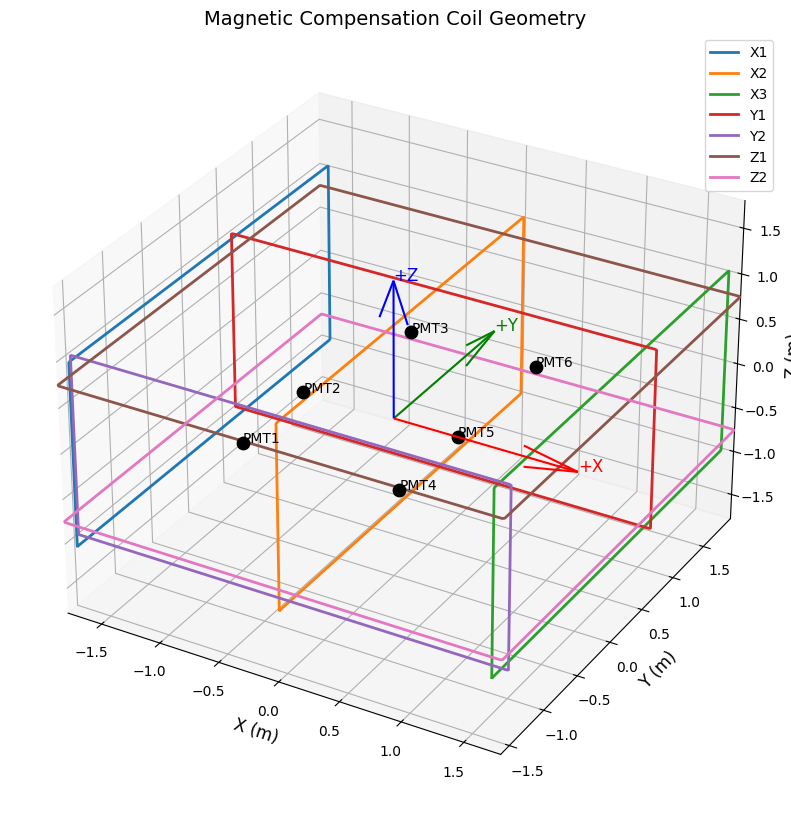

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

import sys
import os

# ============================================================
# Add src folder to path
# ============================================================

src_path = os.path.abspath("../src")

if src_path not in sys.path:
    sys.path.append(src_path)

# ============================================================
# Imports
# ============================================================

from coils import coils
from pmts import PMTs

# ============================================================
# Create figure
# ============================================================

fig = plt.figure(figsize=(12,10))

ax = fig.add_subplot(111, projection='3d')

# ============================================================
# Plot coils
# ============================================================

for coil_name, (segment_centers, dl_vectors) in coils.items():

    x = segment_centers[:,0]
    y = segment_centers[:,1]
    z = segment_centers[:,2]

    ax.plot(
        x,
        y,
        z,
        linewidth=2,
        label=coil_name
    )

# ============================================================
# Plot PMTs
# ============================================================

for pmt_name, position in PMTs.items():

    x, y, z = position

    ax.scatter(
        x,
        y,
        z,
        s=80,
        color='black'
    )

    ax.text(
        x,
        y,
        z,
        pmt_name,
        fontsize=10
    )

# ============================================================
# Coordinate axes
# ============================================================

axis_length = 1.5

ax.quiver(0,0,0, axis_length,0,0, color='r')
ax.quiver(0,0,0, 0,axis_length,0, color='g')
ax.quiver(0,0,0, 0,0,axis_length, color='b')

ax.text(axis_length,0,0,'+X', color='r', fontsize=12)
ax.text(0,axis_length,0,'+Y', color='g', fontsize=12)
ax.text(0,0,axis_length,'+Z', color='b', fontsize=12)

# ============================================================
# Equal aspect ratio
# ============================================================

all_points = []

# Coil points
for segment_centers, _ in coils.values():
    all_points.append(segment_centers)

# PMT points
for position in PMTs.values():
    all_points.append(position.reshape(1,3))

all_points = np.vstack(all_points)

x_limits = [all_points[:,0].min(), all_points[:,0].max()]
y_limits = [all_points[:,1].min(), all_points[:,1].max()]
z_limits = [all_points[:,2].min(), all_points[:,2].max()]

x_range = x_limits[1] - x_limits[0]
y_range = y_limits[1] - y_limits[0]
z_range = z_limits[1] - z_limits[0]

max_range = max(x_range, y_range, z_range)

x_mid = np.mean(x_limits)
y_mid = np.mean(y_limits)
z_mid = np.mean(z_limits)

ax.set_xlim(x_mid - max_range/2, x_mid + max_range/2)
ax.set_ylim(y_mid - max_range/2, y_mid + max_range/2)
ax.set_zlim(z_mid - max_range/2, z_mid + max_range/2)

# ============================================================
# Labels
# ============================================================

ax.set_xlabel("X (m)", fontsize=12)
ax.set_ylabel("Y (m)", fontsize=12)
ax.set_zlabel("Z (m)", fontsize=12)

ax.set_title("Magnetic Compensation Coil Geometry", fontsize=14)

ax.legend()

plt.show()

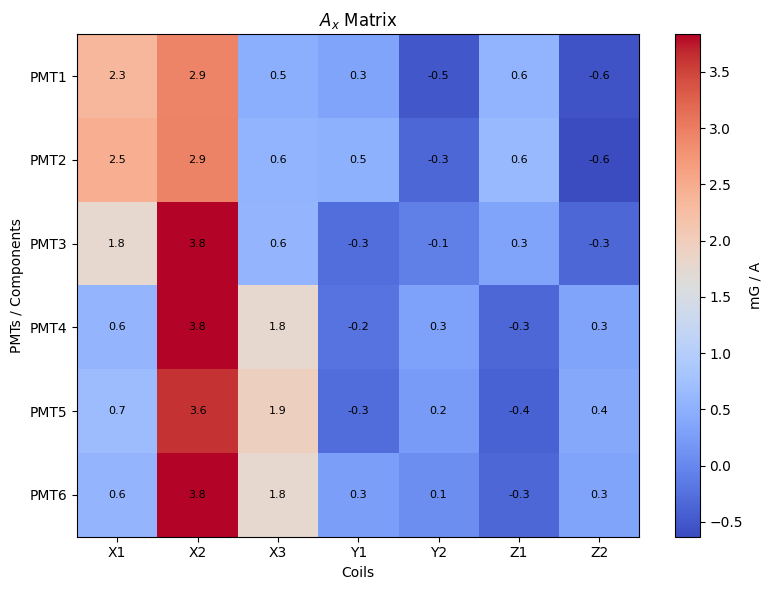

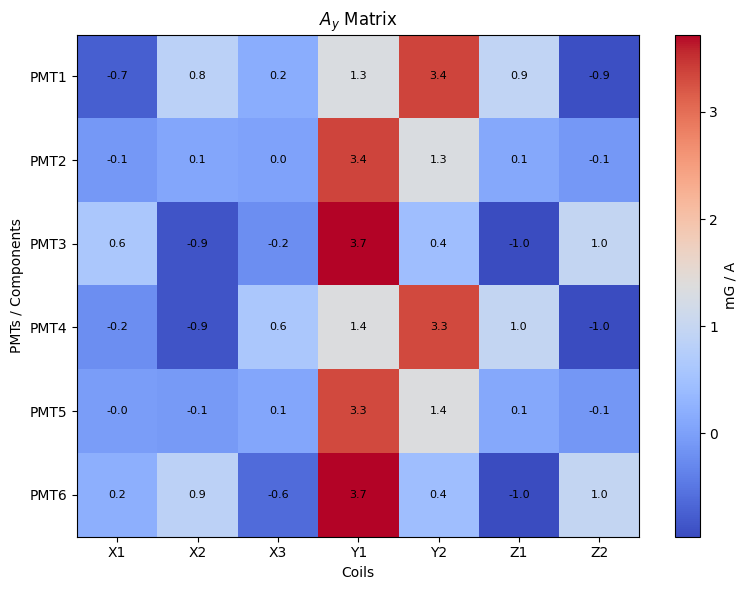

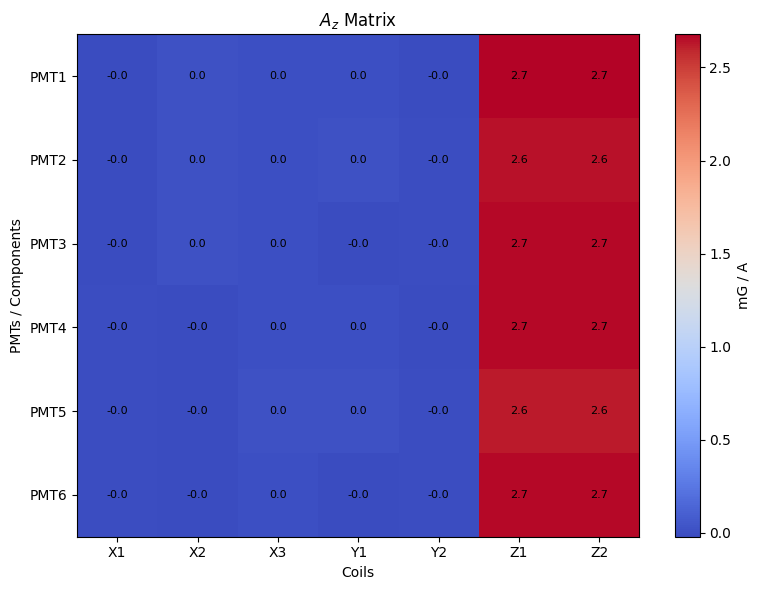

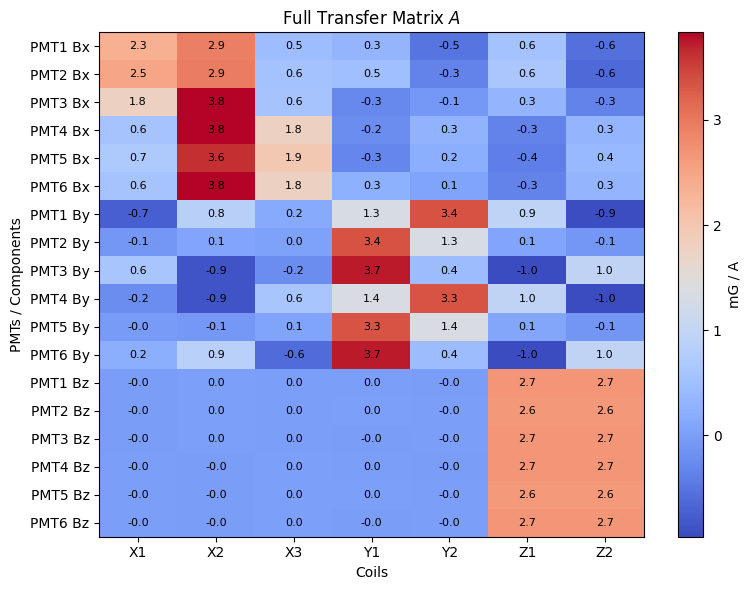

In [2]:
# ============================================================
# HEATMAPS OF MATRICES
# Ax.npy, Ay.npy, Az.npy, A.npy
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# LOAD MATRICES
# ============================================================

project_root = Path.cwd().parent
data_dir = project_root / "data"

Ax = np.load(data_dir / "Ax.npy")
Ay = np.load(data_dir / "Ay.npy")
Az = np.load(data_dir / "Az.npy")
A  = np.load(data_dir / "A.npy")

# ============================================================
# MATRIX LABELS
# ============================================================

coil_labels = [

    'X1', 'X2', 'X3',
    'Y1', 'Y2',
    'Z1', 'Z2'
]

pmt_labels = [

    'PMT1', 'PMT2', 'PMT3',
    'PMT4', 'PMT5', 'PMT6'
]

# ============================================================
# PLOTTING FUNCTION
# ============================================================

def plot_matrix_heatmap(
    matrix,
    title,
    row_labels,
    col_labels,
    cmap='coolwarm'
):

    plt.figure(figsize=(8,6))

    im = plt.imshow(
        matrix,
        aspect='auto',
        cmap=cmap
    )

    # --------------------------------------------------------
    # COLORBAR
    # --------------------------------------------------------

    cbar = plt.colorbar(im)
    cbar.set_label('mG / A')

    # --------------------------------------------------------
    # TICKS
    # --------------------------------------------------------

    plt.xticks(
        np.arange(len(col_labels)),
        col_labels
    )

    plt.yticks(
        np.arange(len(row_labels)),
        row_labels
    )

    # --------------------------------------------------------
    # LABELS
    # --------------------------------------------------------

    plt.xlabel('Coils')
    plt.ylabel('PMTs / Components')

    plt.title(title)

    # --------------------------------------------------------
    # CELL VALUES
    # --------------------------------------------------------

    for i in range(matrix.shape[0]):

        for j in range(matrix.shape[1]):

            plt.text(
                j,
                i,
                f'{matrix[i,j]:.1f}',
                ha='center',
                va='center',
                color='black',
                fontsize=8
            )

    plt.tight_layout()
    plt.show()

# ============================================================
# PLOT Ax
# ============================================================

plot_matrix_heatmap(

    Ax,

    r'$A_x$ Matrix',

    pmt_labels,

    coil_labels
)

# ============================================================
# PLOT Ay
# ============================================================

plot_matrix_heatmap(

    Ay,

    r'$A_y$ Matrix',

    pmt_labels,

    coil_labels
)

# ============================================================
# PLOT Az
# ============================================================

plot_matrix_heatmap(

    Az,

    r'$A_z$ Matrix',

    pmt_labels,

    coil_labels
)

# ============================================================
# PLOT FULL A MATRIX
# ============================================================

A_row_labels = [

    'PMT1 Bx', 'PMT2 Bx', 'PMT3 Bx',
    'PMT4 Bx', 'PMT5 Bx', 'PMT6 Bx',

    'PMT1 By', 'PMT2 By', 'PMT3 By',
    'PMT4 By', 'PMT5 By', 'PMT6 By',

    'PMT1 Bz', 'PMT2 Bz', 'PMT3 Bz',
    'PMT4 Bz', 'PMT5 Bz', 'PMT6 Bz'
]

plot_matrix_heatmap(

    A,

    r'Full Transfer Matrix $A$',

    A_row_labels,

    coil_labels
)